# Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to explore customer behavior, identify churn patterns, and generate business insights using visualizations.

We will analyze:

- Customer demographics
- Service usage
- Contract types
- Payment methods
- Monthly and Total Charges
- Tenure
- Churn patterns

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/clean_telco.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7032, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [6]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

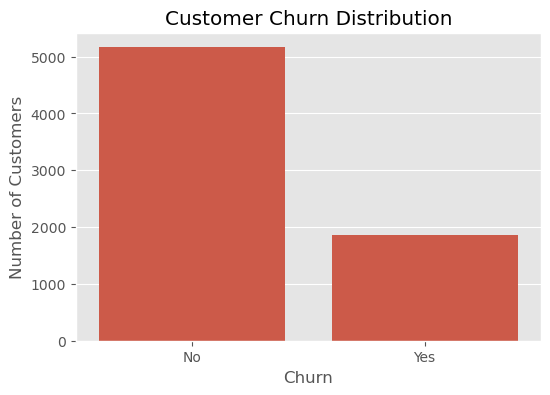

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

### Business Insight

- Majority of customers have not churned.
- Around 26–27% customers have churned.
- Customer retention is higher than customer loss.
- However, losing more than one-fourth of customers is a significant business concern.

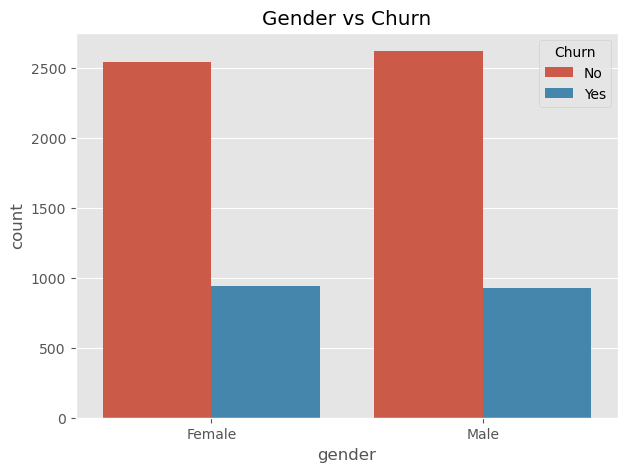

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")

plt.show()

### Insight

Male and Female customers show similar churn patterns.

Gender alone is not a strong predictor of churn.

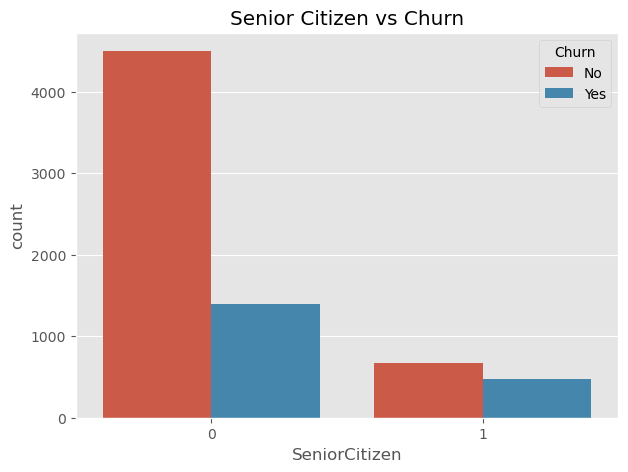

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")

plt.show()

Senior citizens appear to churn at a higher rate compared to younger customers.

This customer segment requires targeted retention strategies.

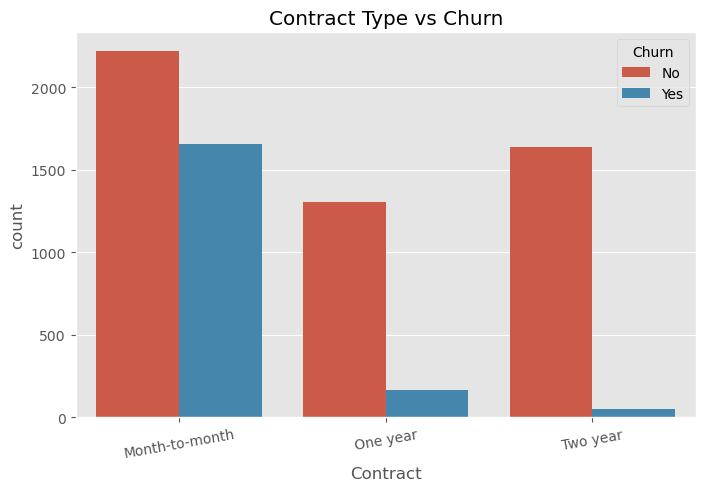

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=10)

plt.show()

Customers with Month-to-Month contracts have the highest churn.

Customers with Two-Year contracts have the lowest churn.

Long-term contracts improve customer retention.

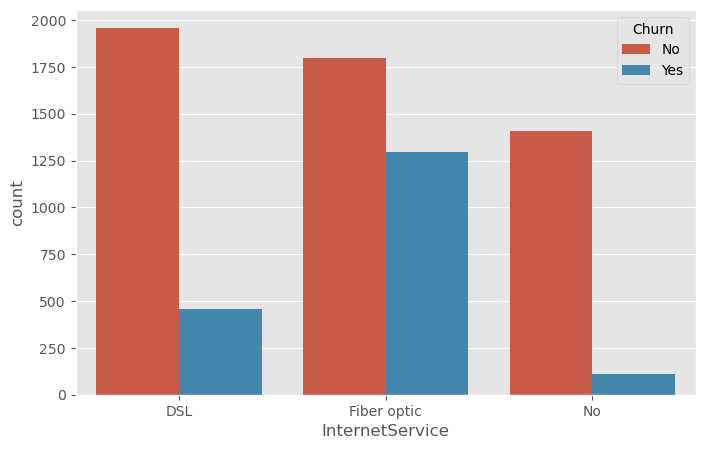

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.show()

Fiber Optic customers have a higher churn rate compared to DSL customers.

This may indicate pricing or service quality concerns.

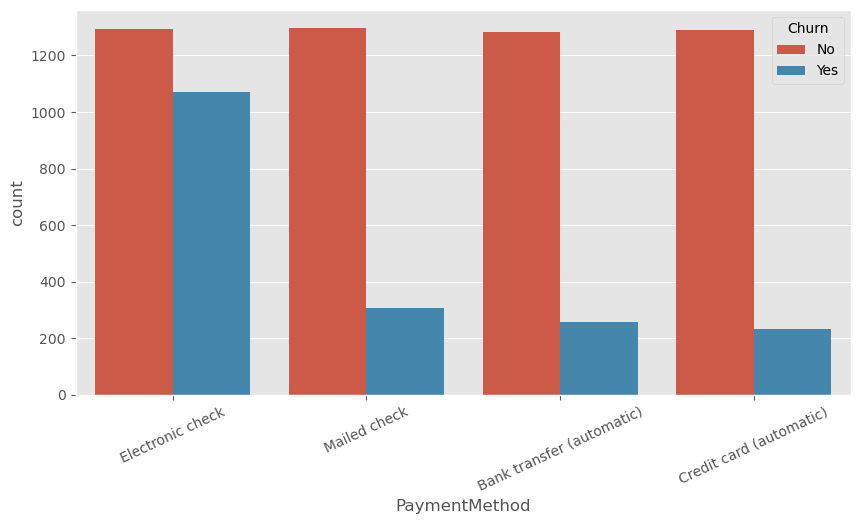

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=25)

plt.show()

Customers using Electronic Check show higher churn.

The company should investigate customer experience with this payment method.

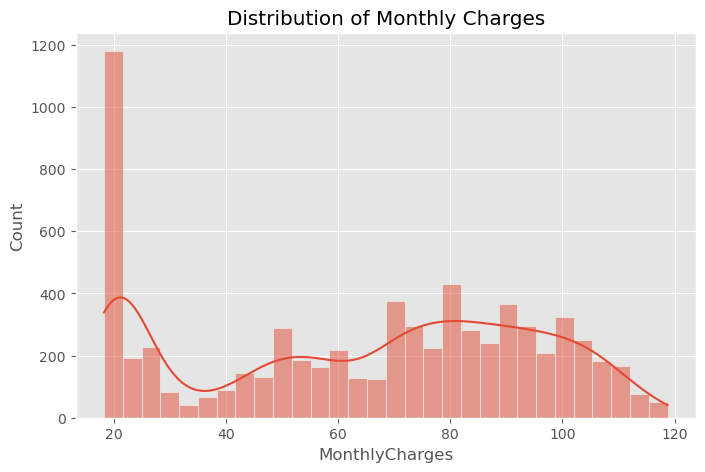

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")

plt.show()

Monthly charges are spread across different price ranges.

Further analysis is required to determine whether higher monthly charges influence churn.

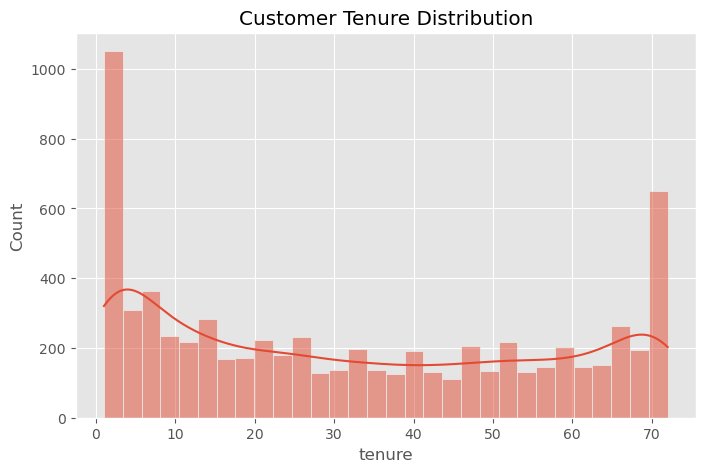

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

Many customers are relatively new, while a large number have remained with the company for several years.

Longer tenure often indicates stronger customer loyalty.

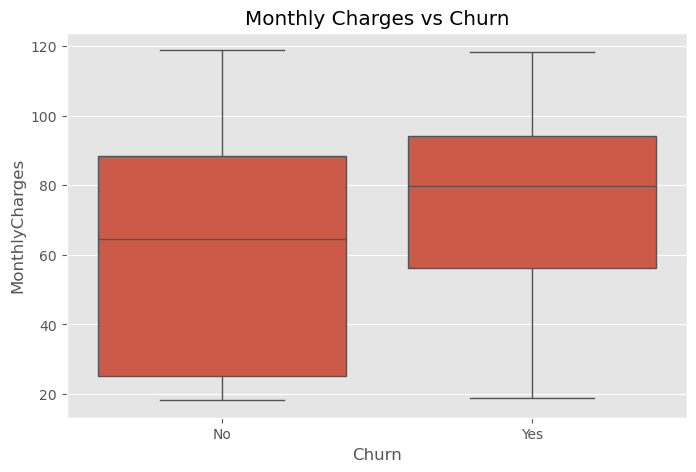

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

### Insight

Customers who churn generally have higher monthly charges.

High monthly subscription costs may be a major reason for customer churn.

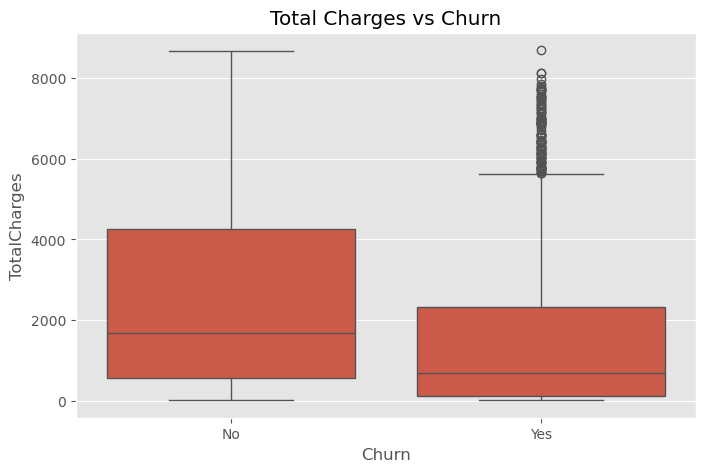

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.show()

### Insight

Customers with higher Total Charges tend to stay longer because Total Charges increase with tenure.

Customers who churn usually have lower Total Charges due to shorter relationships.

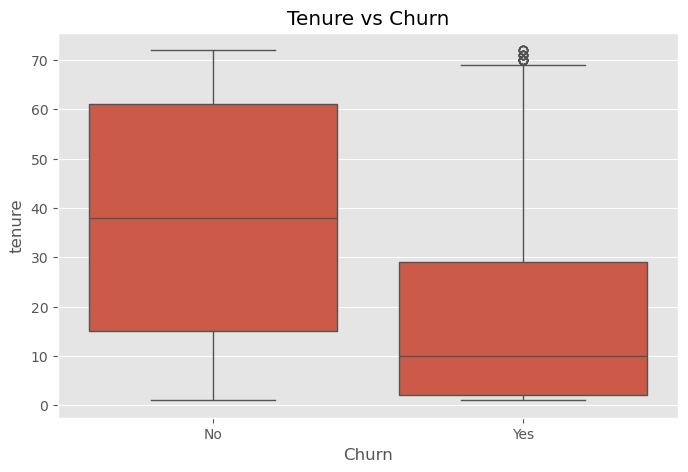

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.show()

### Insight

Customers who churn generally have much lower tenure.

New customers are more likely to leave than long-term customers.

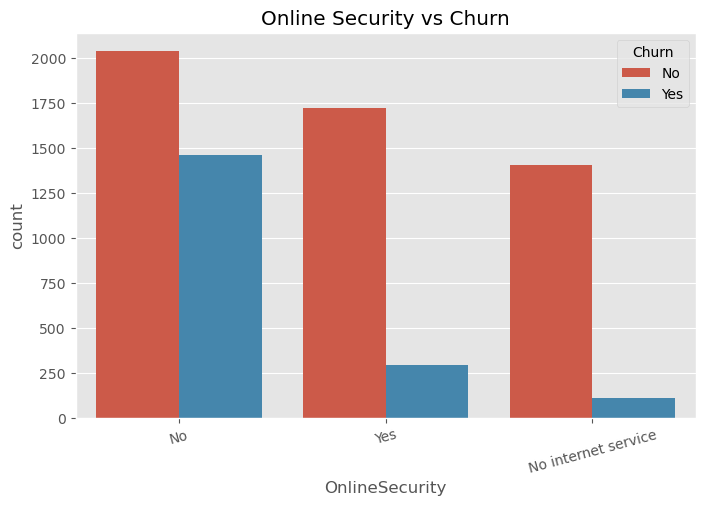

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.xticks(rotation=15)

plt.title("Online Security vs Churn")

plt.show()

### Insight

Customers without Online Security have significantly higher churn.

Security services improve customer retention.

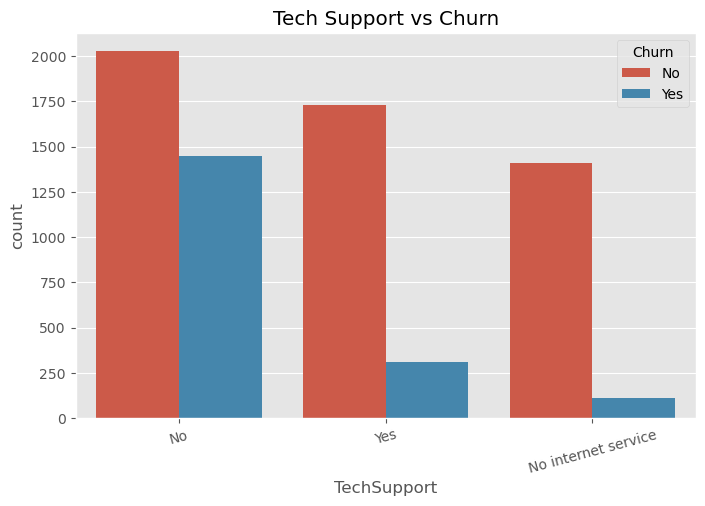

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.xticks(rotation=15)

plt.title("Tech Support vs Churn")

plt.show()

### Insight

Customers without Tech Support churn much more frequently.

Providing quality technical support improves customer satisfaction.

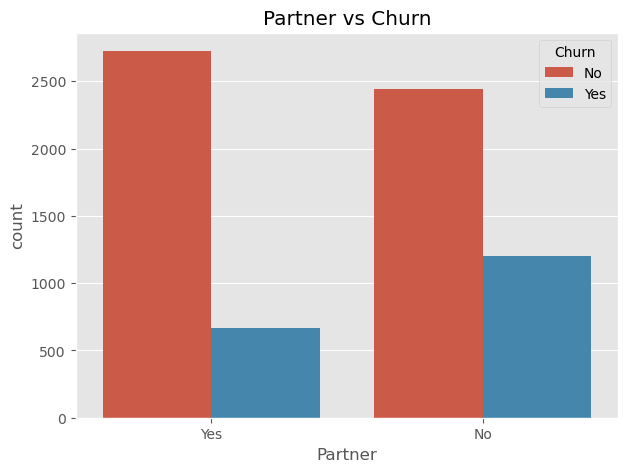

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

plt.title("Partner vs Churn")

plt.show()

### Insight

Customers with partners are slightly less likely to churn.

Family customers appear to be more stable.

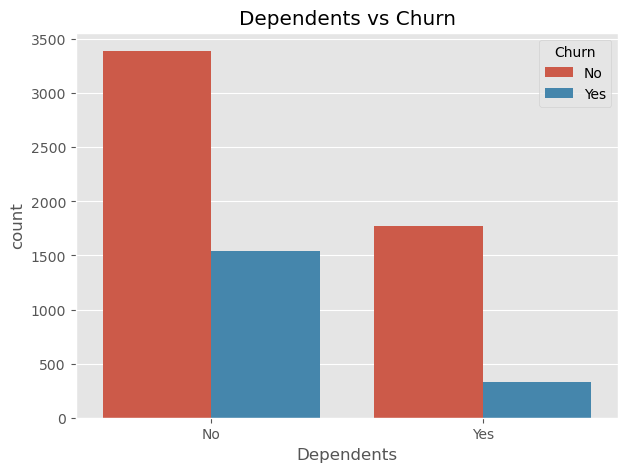

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

plt.title("Dependents vs Churn")

plt.show()

### Insight

Customers with dependents show lower churn.

Family-oriented customers are generally more loyal.

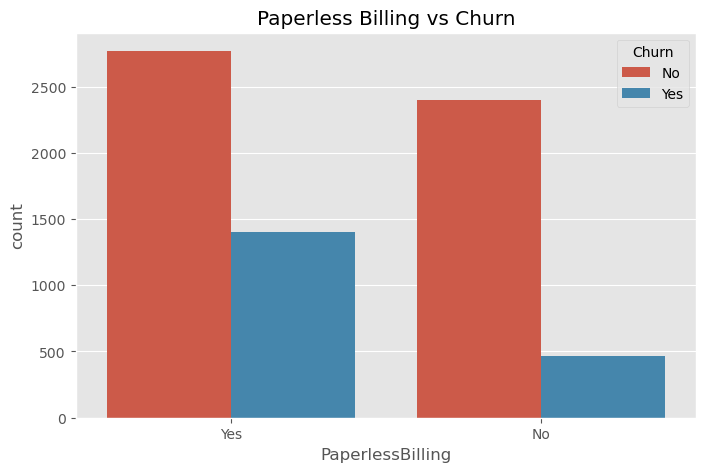

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="PaperlessBilling",
    hue="Churn"
)

plt.title("Paperless Billing vs Churn")

plt.show()

### Insight

Customers using Paperless Billing have a relatively higher churn rate.

Further business investigation is required to understand this trend.

In [24]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

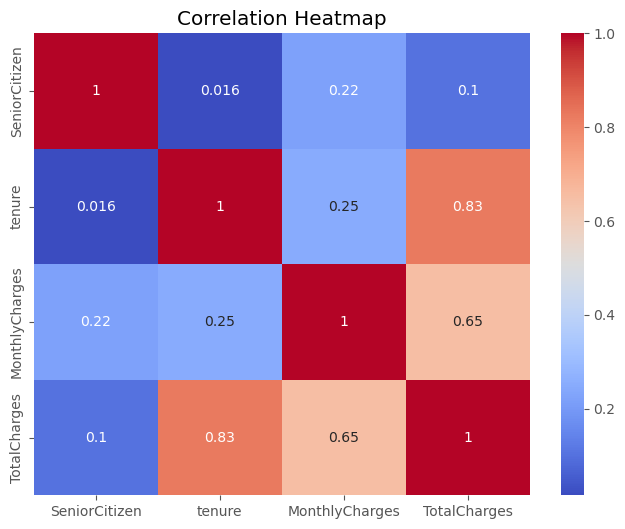

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

Most numerical variables have weak correlations.

Tenure and Total Charges show the strongest positive relationship because longer customer relationships generate higher cumulative charges.

In [26]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

churn_percentage

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

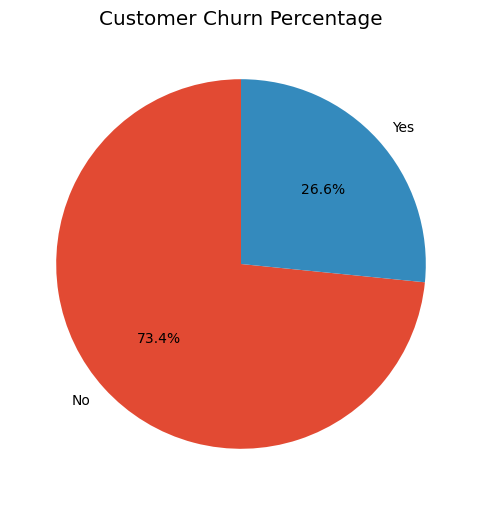

In [27]:
plt.figure(figsize=(6,6))

plt.pie(
    churn_percentage,
    labels=churn_percentage.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

### Insight

Approximately one-fourth of customers have churned.

Reducing churn even by a few percentage points could significantly improve company revenue.

In [28]:
df.groupby("Contract")["MonthlyCharges"].mean().sort_values()

Contract
Two year          60.872374
One year          65.079416
Month-to-month    66.398490
Name: MonthlyCharges, dtype: float64

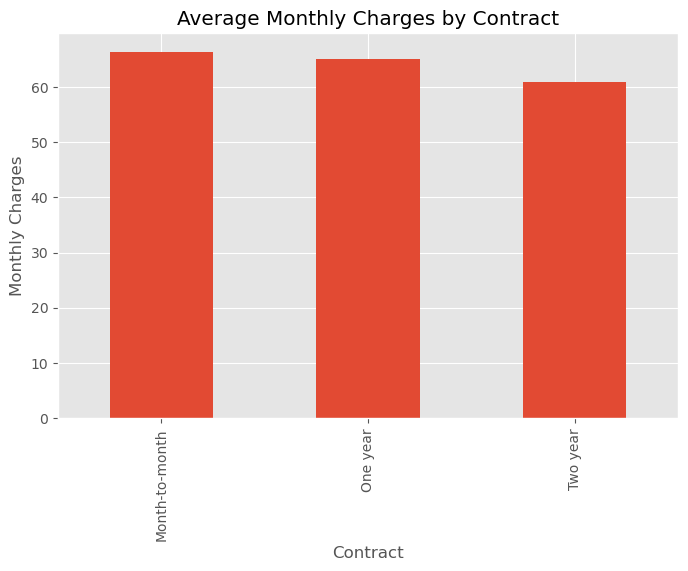

In [29]:
df.groupby("Contract")["MonthlyCharges"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Monthly Charges by Contract")

plt.ylabel("Monthly Charges")

plt.show()

### Insight

Different contract types have different average monthly charges.

Understanding pricing by contract helps design better retention strategies.

# Top Business Insights

1. Month-to-Month customers churn the most.

2. Senior Citizens churn more frequently.

3. High Monthly Charges increase churn.

4. Low Tenure customers churn more.

5. Customers without Tech Support churn more.

6. Customers without Online Security churn more.

7. Electronic Check users churn more.

8. Fiber Optic users churn more.

9. Long-term contracts reduce churn.

10. Customer retention should focus on new customers.